In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

print("First 10 rows:")
print(df.head(10))

print("\nShape of dataset (rows, columns):", df.shape)

print("\nBasic information about the dataset:")
df.info()


First 10 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

In [75]:
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [76]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows found:", duplicate_count)


df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows found: 0
Shape after removing duplicates: (918, 12)


In [77]:
cholesterol_zero_count = (df["Cholesterol"] == 0).sum()

restingbp_zero_count = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0:", cholesterol_zero_count)
print("Rows with RestingBP = 0:", restingbp_zero_count)


Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


In [78]:

print("Statistical summary before cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

cholesterol_mean = df[df["Cholesterol"] != 0, "Cholesterol"].mean()

restingbp_mean = df[df["RestingBP"] != 0, "RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, cholesterol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, restingbp_mean)

df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nStatistical summary after cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())


Statistical summary BEFORE cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

Statistical summary AFTER cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


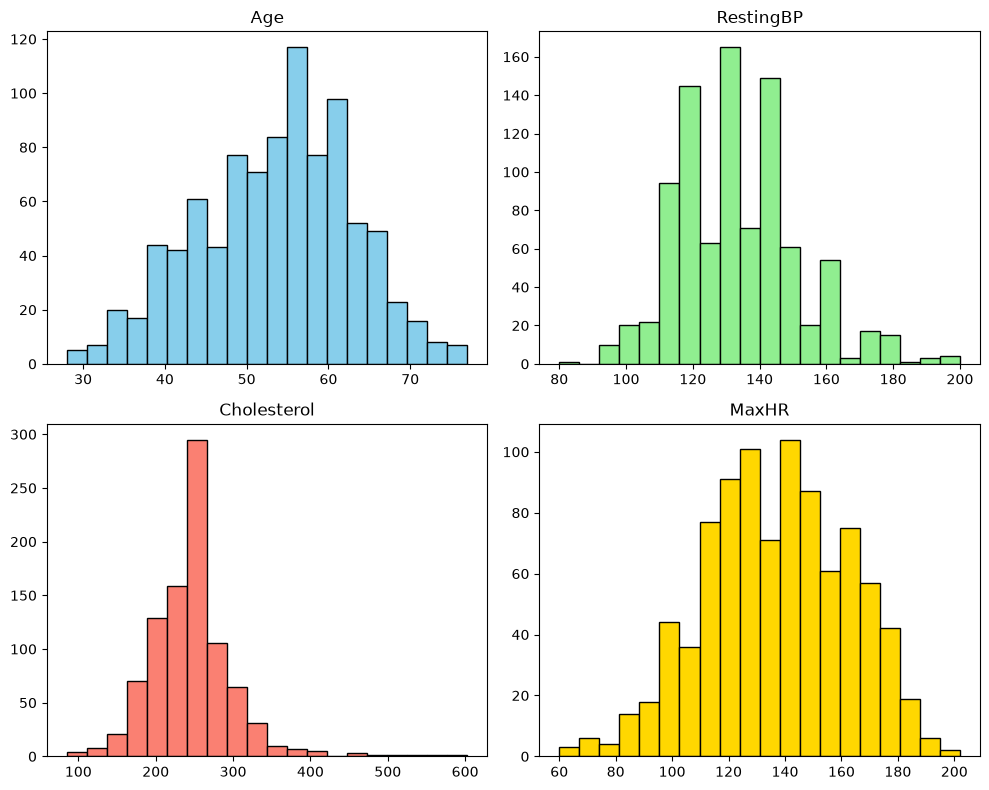

In [79]:
def plot_histograms(data):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].hist(data["Age"], bins=20, color="skyblue", edgecolor="black")
    axes[0, 0].set_title("Age")

    axes[0, 1].hist(data["RestingBP"], bins=20, color="lightgreen", edgecolor="black")
    axes[0, 1].set_title("RestingBP")

    axes[1, 0].hist(data["Cholesterol"], bins=20, color="salmon", edgecolor="black")
    axes[1, 0].set_title("Cholesterol")

    axes[1, 1].hist(data["MaxHR"], bins=20, color="gold", edgecolor="black")
    axes[1, 1].set_title("MaxHR")

    plt.tight_layout()
    plt.show()


plot_histograms(df)


In [ ]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')
Categorical columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


/var/folders/h4/4rfr1rb570q9gnw48hm1d_1c0000gp/T/ipykernel_1621/3821962293.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [81]:
df_encoded = pd.get_dummies(df, columns=categorical_cols)

print("Shape of df_encoded:", df_encoded.shape)

df_encoded.head()


Shape of df_encoded: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [86]:
print("Final shape of df_encoded:", df_encoded.shape)

print("Column names in final dataframe:")
df_encoded.columns


Final shape of df_encoded: (918, 21)
Column names in final dataframe:


['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [ ]:
# 1. What invalid values did you find and how did you fix them?
#the dataset had rows where cholesterol and restingbp
#were o which is not possible so i replaced it with
#mean of non zero columns

# 2. Why is it important to handle invalid values like Cholesterol = 0?
#value of 0 in cholesterol is not medically possible
#and could lead to problems in trained models using this data

# 3. What is the purpose of One-Hot Encoding?
# Machine learning models work with numbers, not text. One-Hot Encoding converts categorical
# (text) columns into multiple binary (0/1) columns, one for each category, so that the data
# can be used in numerical computations and ML models without implying any false order between
# categories.

# 4. Any other observations from the cleaning process.
# - No missing (NaN) values were found in the dataset using isnull().
# - Duplicate rows, if present, were removed to avoid biasing the analysis.
# - After cleaning, the mean values of Cholesterol and RestingBP shifted slightly since the
#   unrealistic 0 values were replaced with realistic averages.
# - One-Hot Encoding increased the number of columns since each categorical column was split
#   into multiple binary columns.